### Section 1 — Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
%matplotlib inline

UsageError: unrecognized arguments: # affiche les graphes dans le notebook


### Section 2 — Chargement + aperçu des données


In [5]:
df_clean = pd.read_parquet(
    Path(r'C:\Users\Abd\Documents\IA_journey\module-0\session-2-pandas\df_clean.parquet')
)

In [6]:
print(f"Shape : {df_clean.shape}")
df_clean.head()

Shape : (1168634, 9)


,date_mutation,valeur_fonciere,code_departement,type_local,surface_reelle_bati,nombre_pieces_principales,prix_m2,annee,mois
1,2023-01-05,1070000.0,01,Appartement,233.0,8.0,4592.274678,2023,1
3,2023-01-03,152200.0,01,Maison,64.0,3.0,2378.125000,2023,1
5,2023-01-05,269000.0,01,Maison,73.0,3.0,3684.931507,2023,1
7,2023-01-03,770000.0,01,Maison,136.0,7.0,5661.764706,2023,1
14,2023-01-06,85520.0,01,Maison,160.0,5.0,534.500000,2023,1


In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168634 entries, 1 to 3812326
Data columns (total 9 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   date_mutation              1168634 non-null  datetime64[ns]
 1   valeur_fonciere            1168634 non-null  float64       
 2   code_departement           1168634 non-null  object        
 3   type_local                 1168634 non-null  object        
 4   surface_reelle_bati        1168634 non-null  float64       
 5   nombre_pieces_principales  1168634 non-null  float64       
 6   prix_m2                    1168634 non-null  float64       
 7   annee                      1168634 non-null  int32         
 8   mois                       1168634 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(2), object(2)
memory usage: 80.2+ MB


In [8]:
df_clean.describe()

,date_mutation,valeur_fonciere,surface_reelle_bati,nombre_pieces_principales,prix_m2,annee,mois
count,1168634,1.168634e+06,1.168634e+06,1.168634e+06,1.168634e+06,1168634.0,1.168634e+06
mean,2023-07-01 13:32:36.173104384,3.273586e+05,1.033601e+02,3.151622e+00,4.237576e+03,2023.0,6.474788e+00
min,2023-01-02 00:00:00,1.500000e+02,1.000000e+00,0.000000e+00,1.000200e+02,2023.0,1.000000e+00
25%,2023-03-31 00:00:00,1.200000e+05,4.900000e+01,2.000000e+00,1.666667e+03,2023.0,3.000000e+00
50%,2023-06-30 00:00:00,2.000000e+05,7.500000e+01,3.000000e+00,2.723184e+03,2023.0,6.000000e+00
75%,2023-09-28 00:00:00,3.300000e+05,1.040000e+02,4.000000e+00,4.545455e+03,2023.0,9.000000e+00
max,2023-12-31 00:00:00,1.730360e+08,8.243300e+04,9.500000e+01,4.999975e+04,2023.0,1.200000e+01
std,NaN,1.062380e+06,3.874043e+02,1.806990e+00,5.372389e+03,0.0,3.405423e+00


## Section 3 — Nettoyage (résumé)

Les étapes de nettoyage ont été effectuées en session 2 :
- Sélection des colonnes utiles
- Suppression des NaN sur valeur_fonciere et surface_reelle_bati
- Création de prix_m2 = valeur_fonciere / surface_reelle_bati
- Suppression des valeurs aberrantes (prix_m2 < 100 ou > 50 000)
- Extraction de l'année et du mois depuis date_mutation

Les données nettoyées sont chargées depuis df_clean.parquet.

### Section 4 — Distributions (histogramme Paris/Lyon + boxplot)

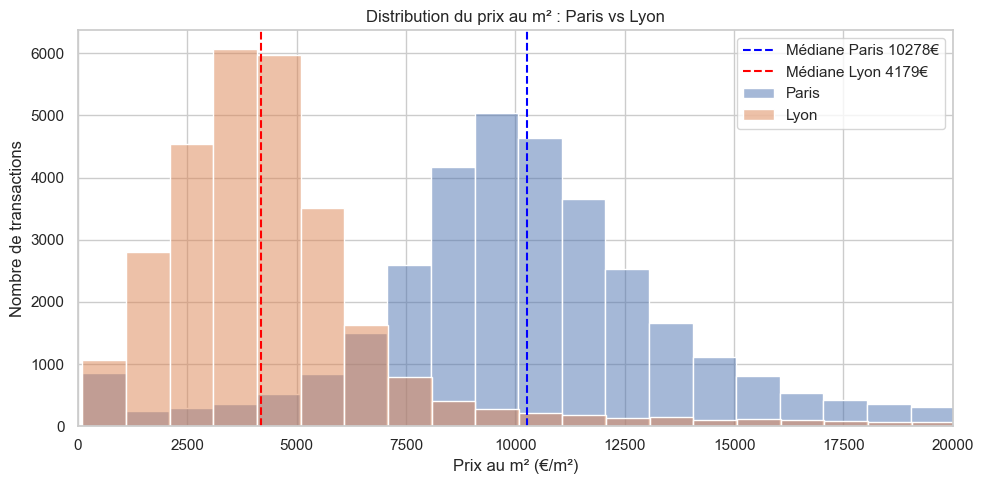

In [11]:
df_paris = df_clean.loc[df_clean['code_departement'] == '75']
df_lyon  = df_clean.loc[df_clean['code_departement'] == '69']

mediane_paris = df_paris['prix_m2'].median()
mediane_lyon  = df_lyon['prix_m2'].median()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(data=df_paris, x='prix_m2', bins=50, alpha=0.5, label='Paris', ax=ax)
sns.histplot(data=df_lyon,  x='prix_m2', bins=50, alpha=0.5, label='Lyon',  ax=ax)

ax.axvline(x=mediane_paris, color='blue', linestyle='--',
           label=f'Médiane Paris {mediane_paris:.0f}€')
ax.axvline(x=mediane_lyon,  color='red',  linestyle='--',
           label=f'Médiane Lyon {mediane_lyon:.0f}€')

ax.set_xlim(0, 20000)
ax.set_xlabel("Prix au m² (€/m²)")
ax.set_ylabel("Nombre de transactions")
ax.set_title("Distribution du prix au m² : Paris vs Lyon")
ax.legend()
plt.tight_layout()
plt.show()

Observations :
- Deux distributions du prix du m^2 quasi-disjointes : Lyon [1000-6000], Paris [6000-15000]
- Les deux sont right-skewed (queue longue à droite) — typique des prix immo
- Médiane Paris ~10 278€/m², Lyon ~4 179€/m² — facteur 2.5
- Implication pour la modélisation : travailler sur log(prix_m2) plutôt
  que prix_m2 directement (distribution log-normale plus adaptée)


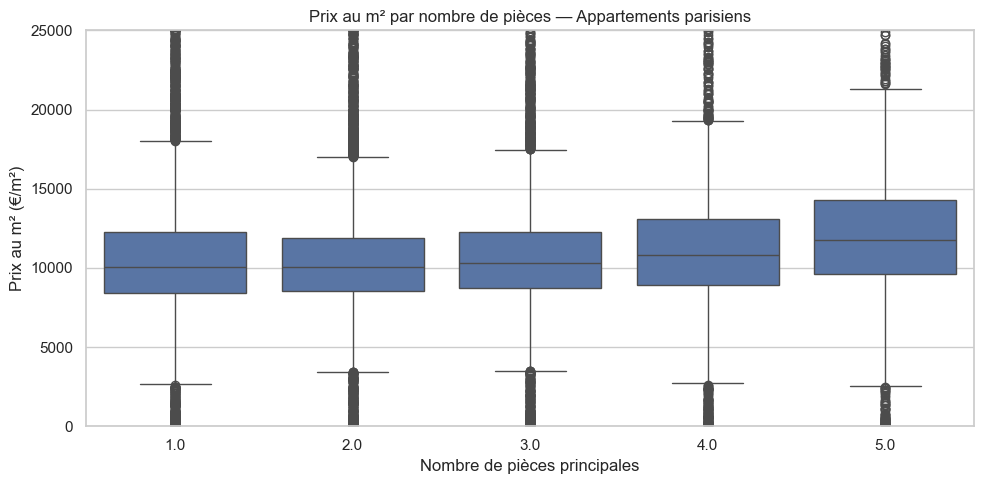

In [12]:
paris_apparts = df_clean.loc[
    (df_clean['type_local'] == 'Appartement') &
    (df_clean['code_departement'] == '75') &
    (df_clean['nombre_pieces_principales'].between(1, 5))
]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=paris_apparts, x='nombre_pieces_principales', y='prix_m2', ax=ax)

ax.set_ylim(0, 25000)
ax.set_xlabel("Nombre de pièces principales")
ax.set_ylabel("Prix au m² (€/m²)")
ax.set_title("Prix au m² par nombre de pièces — Appartements parisiens")
plt.tight_layout()
plt.show()

Prix du m^2 par nombre de pièces pour les appartements parisiens.


Observations :
- Médiane stable entre 1 et 5 pièces (~10 000€/m²)
- Hausse significative à partir de 6 pièces — marché du luxe
- Variance croissante avec le nombre de pièces — marché plus hétérogène
  sur les grands biens

### Section 5 — Relations (scatter + heatmap)

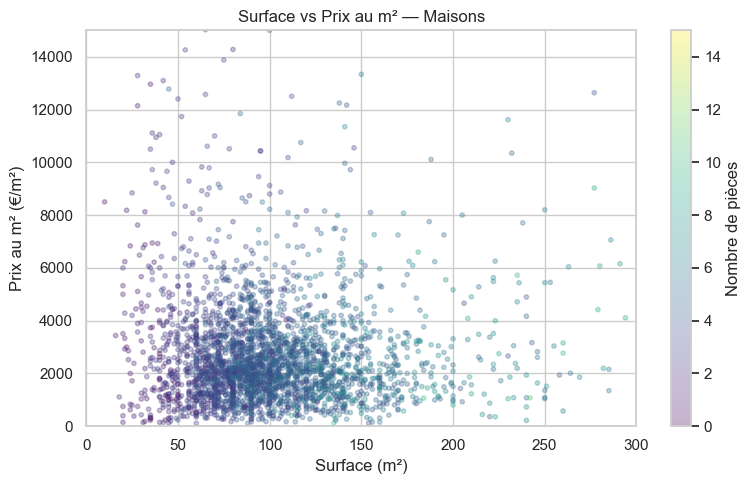

In [13]:
sample = df_clean[df_clean['type_local'] == 'Maison'].sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    sample['surface_reelle_bati'],
    sample['prix_m2'],
    c=sample['nombre_pieces_principales'],
    alpha=0.3, s=10, cmap='viridis'
)
plt.colorbar(sc, ax=ax, label='Nombre de pièces')

ax.set_xlim(0, 300)
ax.set_ylim(0, 15000)
ax.set_xlabel("Surface (m²)")
ax.set_ylabel("Prix au m² (€/m²)")
ax.set_title("Surface vs Prix au m² — Maisons")
plt.tight_layout()
plt.show()

Observations :
- Tendance négative confirmée : plus la surface est grande, moins le prix
  au m² est élevé (décote sur les grandes surfaces)
- Points violets (peu de pièces) concentrés en bas à gauche
- Points jaunes (beaucoup de pièces) à droite — surface et pièces corrélées
- Forte concentration sous 100m² — les grandes maisons sont rares

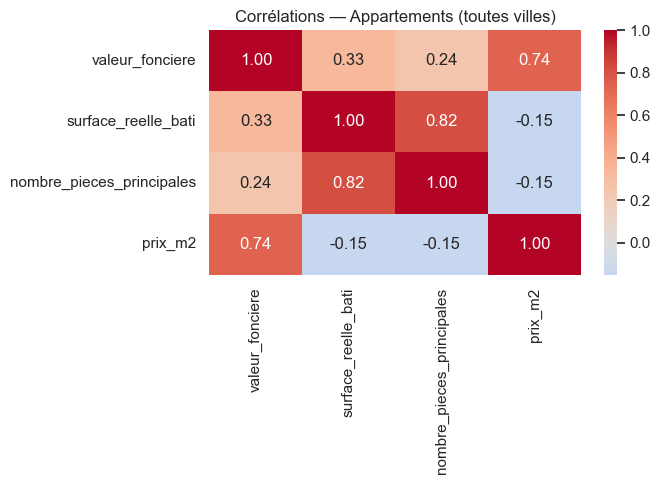

In [14]:
colonnes = ['valeur_fonciere', 'surface_reelle_bati',
            'nombre_pieces_principales', 'prix_m2']

apparts = df_clean.loc[df_clean['type_local'] == 'Appartement']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(apparts[colonnes].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax)
ax.set_title("Corrélations — Appartements (toutes villes)")
plt.tight_layout()
plt.show()

Enseignements :
- surface vs pièces passe de -0.02 à 0.82 — cohérent, plus de pièces = plus grand
- valeur vs prix_m2 passe de 0.29 à 0.74 — à Paris la surface varie peu,
  donc valeur et prix/m² sont très liés
- La segmentation révèle des structures masquées par l'hétérogénéité globale
- Principe : toujours segmenter avant d'analyser les corrélations

### Section 6 — Conclusions (3-5 insights en markdown)

Les principales conclusions de cette EDA :

- Paris et Lyon sont deux marchés structurellement différents (facteur 2.5 sur le prix médian)
- Les distributions de prix sont right-skewed — utiliser la médiane, pas la moyenne
- Plus la surface est grande, moins le prix au m² est élevé (décote confirmée)
- Les corrélations n'ont de sens que sur des données segmentées — l'hétérogénéité globale noie le signal